


# Lecture 4 Code Companion: Gradient Descent and Logistic Regression

## Applied Machine Learning


<font size="4">__Kyra Gan__<br>Cornell Tech <br>
    </font>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 4]

In [2]:
# run the following code to get pytorch up-to-date to version 2.4
# !pip3 install --upgrade torch torchvision torchaudio

## Autograd

* `autograd` in Pytorch
* Example: $$\ell(\theta) = 0.5 (2\theta_1 -2)^2 + 0.5(\theta_0 -3)^2$$ 

In [3]:
import torch
print(torch.__version__)
theta, theta_prev = np.array([-2., 3.]), np.array([0., 0.])
theta_tensor = torch.tensor(theta)
print(theta_tensor)

2.4.1
tensor([-2.,  3.], dtype=torch.float64)


*`requires_grad=True` specify the variables that I want to take gradient with respect to

In [4]:
theta_tensor = torch.tensor(theta, requires_grad = True)
print(theta_tensor)

tensor([-2.,  3.], dtype=torch.float64, requires_grad=True)


* Next, we pass `theta_tensor` through loss function

In [5]:
f = 0.5 * (2*theta_tensor[1]-2)**2 + 0.5*(theta_tensor[0]-3)**2
print(f)

tensor(20.5000, dtype=torch.float64, grad_fn=<AddBackward0>)


* Call function `.backward()` on `g`
* Retreive the derivative by `theta_tensor.grad`

In [6]:
f.backward()
print(theta_tensor.grad)
print(theta_tensor)

tensor([-5.,  8.], dtype=torch.float64)
tensor([-2.,  3.], dtype=torch.float64, requires_grad=True)


* You can confirm we got the same gradient as our closed-form solution


# Gradient Descent in Linear Models

Let's now use gradient descent to derive a supervised learning algorithm for linear models. 

Recall that a linear model has the form
\begin{align*}
y & = \theta_0 + \theta_1 \cdot x_1 + \theta_2 \cdot x_2 + ... + \theta_d \cdot x_d
\end{align*}
where $x \in \mathbb{R}^d$ is a vector of features and $y$ is the target. The $\theta_j$ are the *parameters* of the model.


$$ f_\theta(x) = \sum_{j=0}^d \theta_j \cdot x_j = \theta^\top x. $$

Let's define our model in Python.

In [7]:
def f(X, theta):
    """The linear model we are trying to fit.
    
    Parameters:
    theta (torch.tensor): d-dimensional vector of parameters
    X (torch.tensor): (n,d)-dimensional data matrix
    
    Returns:
    y_pred (torch.tensor): n-dimensional vector of predicted targets
    """
    return torch.matmul(X, theta)

## Mean Squared Error

we are going to import the mean squared error from pytorch and calculate the gradient using autograd

In [8]:
from torch.nn.functional import mse_loss

## The UCI Diabetes Dataset

In this section, we are going to again use the UCI Diabetes Dataset.
* For each patient we have a access to their BMI and an estimate of diabetes risk (from 0-400).
* We are interested in understanding how BMI affects an individual's diabetes risk.

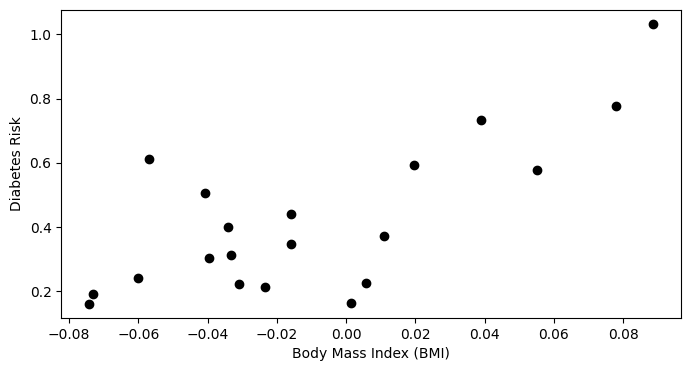

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 4]

import numpy as np
import pandas as pd
from sklearn import datasets

# Load the diabetes dataset
X, y = datasets.load_diabetes(return_X_y=True, as_frame=True)

# add an extra column of onens
X['one'] = 1

# Collect 20 data points and only use bmi dimension
X_train = X.iloc[-20:].loc[:, ['bmi', 'one']]
y_train = y.iloc[-20:] / 300

plt.scatter(X_train.loc[:,['bmi']], y_train,  color='black')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Diabetes Risk')

# we need to convert the training and testing data into torch tensor as well
X_train = torch.tensor(X_train.to_numpy())
y_train = torch.tensor(y_train.to_numpy())

# Gradient Descent for Linear Regression

Putting this together with the gradient descent algorithm, we obtain a learning method for training linear models.


```python
theta, theta_prev = random_initialization()
while abs(J(theta) - J(theta_prev)) > conv_threshold:
    loss = mse_loss(prediction, y_train)
    loss.backward()
    theta_prev = theta
    theta = theta_prev - step_size * theta.gradient
    theta = theta.require_grad_()
```

This update rule is also known as the Least Mean Squares (LMS) or Widrow-Hoff learning rule.

In [10]:
threshold = 1e-5
step_size = 0.1
# initialize theta
theta = torch.tensor(np.array([2.,1.]), requires_grad = True)
theta_prev = torch.tensor(np.ones(2,), requires_grad = True)
iter = 0

while torch.linalg.norm(theta - theta_prev) > threshold:
    theta_prev = theta
    # we first calculate the prediction on the training dataset
    prediction = f(X_train, theta)
    loss = mse_loss(prediction, y_train)
    loss.backward()
    
    with torch.no_grad():  # No need to track history for weight updates
        theta = theta_prev - step_size * theta.grad
        # attaching the gradient after the update step
        theta = theta.requires_grad_()
    
    iter += 1
    if iter % 100 == 0:
        print('Iteration %d. MSE: %.6f' % (iter, loss))

Iteration 100. MSE: 0.030006
Iteration 200. MSE: 0.029534
Iteration 300. MSE: 0.029100
Iteration 400. MSE: 0.028701
Iteration 500. MSE: 0.028335
Iteration 600. MSE: 0.027998
Iteration 700. MSE: 0.027689
Iteration 800. MSE: 0.027404
Iteration 900. MSE: 0.027143
Iteration 1000. MSE: 0.026903
Iteration 1100. MSE: 0.026682
Iteration 1200. MSE: 0.026479
Iteration 1300. MSE: 0.026293
Iteration 1400. MSE: 0.026121
Iteration 1500. MSE: 0.025964
Iteration 1600. MSE: 0.025819
Iteration 1700. MSE: 0.025686
Iteration 1800. MSE: 0.025564
Iteration 1900. MSE: 0.025452
Iteration 2000. MSE: 0.025349
Iteration 2100. MSE: 0.025254
Iteration 2200. MSE: 0.025167
Iteration 2300. MSE: 0.025087
Iteration 2400. MSE: 0.025013
Iteration 2500. MSE: 0.024945
Iteration 2600. MSE: 0.024883
Iteration 2700. MSE: 0.024826
Iteration 2800. MSE: 0.024773
Iteration 2900. MSE: 0.024725
Iteration 3000. MSE: 0.024681
Iteration 3100. MSE: 0.024640
Iteration 3200. MSE: 0.024603
Iteration 3300. MSE: 0.024568
Iteration 3400. MSE

In [11]:
print(theta.detach().numpy())

[3.71421938 0.45772775]


Text(0, 0.5, 'Diabetes Risk')

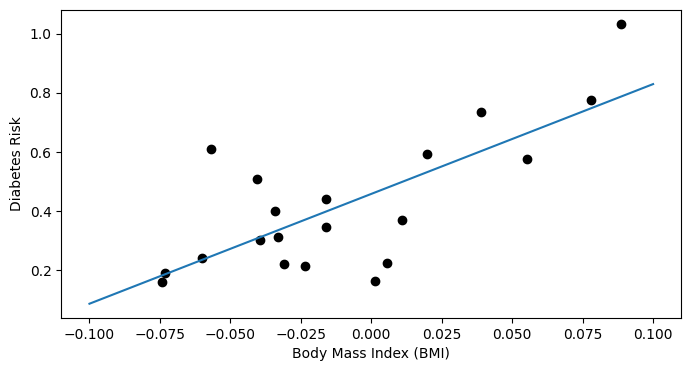

In [12]:
x_line = np.stack([np.linspace(-0.1, 0.1, 10), np.ones(10,)])
y_line = theta.detach().numpy().dot(x_line)

plt.scatter(X_train.numpy()[:,0], y_train.numpy(),  color='black')
plt.plot(x_line[0], y_line)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Diabetes Risk')

In [13]:
# you can cross check your answer with sklearn

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Mean Squared Error: 0.024177787873230695
Coefficients: [3.73788422 0.        ]
Intercept: 0.4579643832623464


# Binary Classification

An important special case of classification is when the number of classes $K=2$.

In this case, we have an instance of a *binary classification* problem.

# An Example: Classifying Iris Flowers

Our running example for classification problems will be the __iris flower dataset__. 

This is a classical dataset originally published by [R. A. Fisher](https://en.wikipedia.org/wiki/Ronald_Fisher) in 1936. 
<!-- Nowadays, it's often used for demonstrating machine learning algorithms. -->

Let's import the dataset from `sklearn`.

In [14]:
import numpy as np
import pandas as pd
from sklearn import datasets
import warnings
warnings.filterwarnings('ignore')

# Load the Iris dataset
iris = datasets.load_iris(as_frame=True)

print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

Below, we print out five random rows of this dataset.

In [15]:
# print part of the dataset
iris_X, iris_y = iris.data, iris.target
pd.concat([iris_X, iris_y], axis=1).sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
57,4.9,2.4,3.3,1.0,1
18,5.7,3.8,1.7,0.3,0
109,7.2,3.6,6.1,2.5,2
4,5.0,3.6,1.4,0.2,0
31,5.4,3.4,1.5,0.4,0



We will to start by looking at __binary__ (two-class) classification. 

To keep things simple, we will use the Iris dataset. We will attempt to distinguish class 0 (Iris Setosa) from the other two classes.

We only use the first two features in the dataset. Our task is to tell apart Setosa flowers from non-Setosa flowers.

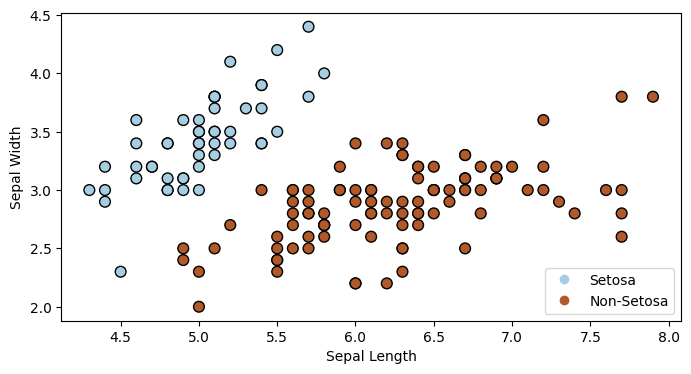

In [16]:
# rename class two to class one
iris_y2 = iris_y.copy()
iris_y2[iris_y2==2] = 1

# Plot also the training points
p1 = plt.scatter(iris_X.iloc[:, 0], iris_X.iloc[:, 1], c=iris_y2,
            edgecolor='k', s=60, cmap=plt.cm.Paired)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(handles=p1.legend_elements()[0], labels=['Setosa', 'Non-Setosa'], loc='lower right')

## Ordinary Least Squares
We could use least squares to solve our classification problem, setting $\mathcal{Y} = \{0, 1\}$.

In [17]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
X, Y = iris_X.to_numpy()[:,:2], iris_y2
linreg.fit(X, Y)

LinearRegression()

Ordinary least squares returns a decision boundary that is not unreasonable.

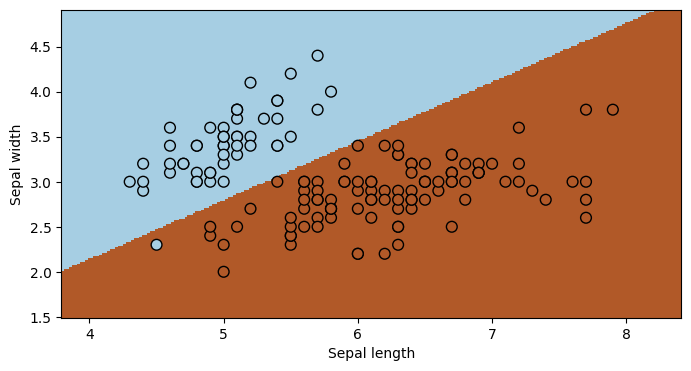

In [18]:
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = linreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z[Z>0.5] = 1
Z[Z<0.5] = 0

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k', cmap=plt.cm.Paired, s=60)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.show()

However, applying OLS is problematic for a few reasons.
* __Unbounded ouputs__: There is nothing to prevent outputs larger than one or smaller than zero, which is conceptually wrong
* __Performance issues:__ At least one point is misclassified, and others are too close to the decision boundary.

# Logistic Regression: The Model

Logistic regression is a classification algorithm where $f_\theta$ has the form
$$ f_\theta(x) = \sigma(\theta^\top x) = \frac{1}{1 + \exp(-\theta^\top x)}. $$

This is a composition of a linear model $\theta^\top x$ with 
$$ \sigma(z) = \frac{1}{1 + \exp(-z)} $$
is the *sigmoid* or *logistic* function.

Let's train a classification algorithm called __logistic regression__.

In [20]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(C=1e5)
X, Y = iris_X.to_numpy()[:,:2], iris_y2
logreg.fit(X, Y) 

LogisticRegression(C=100000.0)

Plot the decision boundary below

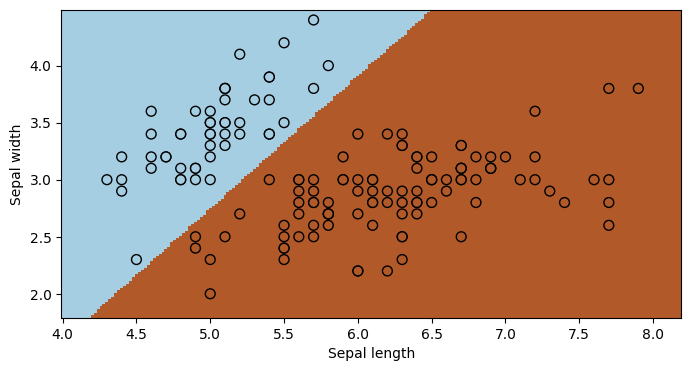

In [21]:
xx, yy = np.meshgrid(np.arange(4, 8.2, .02), np.arange(1.8, 4.5, .02))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the training points
plt.scatter(iris_X.iloc[:, 0], iris_X.iloc[:, 1], c=iris_y2, edgecolors='k', cmap=plt.cm.Paired, s=50)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.show()